In [1]:
import numpy as np
import torch
from datasets import load_dataset
from torch.utils.data import DataLoader, TensorDataset
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from gensim.corpora import Dictionary
from torch import nn, optim
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
import random
import nltk
import gensim.downloader

resources = ['punkt_tab', 'punkt', 'stopwords', 'wordnet', 'omw-1.4']
for r in resources:
    nltk.download(r)

/Users/ashutosh/PycharmProjects/LSTM_FeedForward_With_Transfer Learning/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/ashutosh/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /Users/ashutosh/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/ashutosh/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/ashutosh/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/ashutosh/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-d

In [2]:
# Random seed for reproducibility
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [3]:
set_seed(50)

In [4]:
# Stopwords and lemmatizer setup
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/ashutosh/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/ashutosh/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/ashutosh/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [5]:
# Text Preprocessing Function
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+|#', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = word_tokenize(text)
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    text = ' '.join(words)
    return text

In [6]:
cache_dir = "./data_cache"
train_dataset = load_dataset("tweet_eval", name="emotion", split="train", cache_dir=cache_dir)
val_dataset = load_dataset("tweet_eval", name="emotion", split="validation", cache_dir=cache_dir)
test_dataset = load_dataset("tweet_eval", name="emotion", split="test", cache_dir=cache_dir)

In [7]:
# Text preprocessing
train_texts = [clean_text(text) for text in train_dataset['text']]
val_texts = [clean_text(text) for text in val_dataset['text']]
test_texts = [clean_text(text) for text in test_dataset['text']]

In [8]:
# Convert labels to numpy arrays
train_labels = np.array(train_dataset['label'])
val_labels = np.array(val_dataset['label'])
test_labels = np.array(test_dataset['label'])

In [9]:
# Building vocabulary using Tokenization
def tokenize_and_build_vocab(texts):
    tokenized_texts = [list(word_tokenize(text)) for text in texts]
    dictionary = Dictionary(tokenized_texts)
    return tokenized_texts, dictionary

tokenized_train_texts, dictionary = tokenize_and_build_vocab(train_texts)
vocab_size = len(dictionary) + 1  # Add one for padding token

In [10]:
# Tokens conversion to input IDs
def tokens_to_ids(tokenized_texts, dictionary):
    input_ids = []
    for tokens in tokenized_texts:
        ids = [dictionary.token2id[token] + 1 for token in tokens if token in dictionary.token2id]
        input_ids.append(ids)
    return input_ids

In [11]:
train_input_ids = tokens_to_ids(tokenized_train_texts, dictionary)
val_input_ids = tokens_to_ids([list(word_tokenize(text)) for text in val_texts], dictionary)
test_input_ids = tokens_to_ids([list(word_tokenize(text)) for text in test_texts], dictionary)

In [12]:
# Pad sequences
sequence_length = 30  # Maximum sequence length

In [13]:
def pad_sequences(input_ids, sequence_length):
    padded_input_ids = []
    for ids in input_ids:
        if len(ids) > sequence_length:
            padded_input_ids.append(ids[:sequence_length])
        else:
            padded_input_ids.append([0] * (sequence_length - len(ids)) + ids)
    return padded_input_ids

In [14]:
train_input_ids = pad_sequences(train_input_ids, sequence_length)
val_input_ids = pad_sequences(val_input_ids, sequence_length)
test_input_ids = pad_sequences(test_input_ids, sequence_length)

In [15]:
# Creating Tensors from the input vectors
train_inputs_tensor = torch.tensor(train_input_ids, dtype=torch.long)
train_labels_tensor = torch.tensor(train_labels, dtype=torch.long)
val_inputs_tensor = torch.tensor(val_input_ids, dtype=torch.long)
val_labels_tensor = torch.tensor(val_labels, dtype=torch.long)
test_inputs_tensor = torch.tensor(test_input_ids, dtype=torch.long)
test_labels_tensor = torch.tensor(test_labels, dtype=torch.long)

In [16]:
# Create DataLoader
batch_size = 64
train_dataset = TensorDataset(train_inputs_tensor, train_labels_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataset = TensorDataset(val_inputs_tensor, val_labels_tensor)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataset = TensorDataset(test_inputs_tensor, test_labels_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [17]:
# Load GloVe embeddings
glove_vectors = gensim.downloader.load('glove-twitter-50')


In [18]:
# Create embedding matrix
embedding_matrix = np.zeros((vocab_size, glove_vectors.vector_size))
for word, idx in dictionary.token2id.items():
    if word in glove_vectors:
        embedding_matrix[idx + 1] = glove_vectors[word]  # idx + 1 because we added 1 for padding token

In [19]:
# Create LSTM model class to use pretrained embeddings
class LSTMTextClassifierWithEmbeddings(nn.Module):
    def __init__(self, hidden_size, sequence_length, num_classes, embedding_matrix):
        super(LSTMTextClassifierWithEmbeddings, self).__init__()
        self.embedding_size = embedding_matrix.shape[1]
        self.embedding_layer = nn.Embedding.from_pretrained(torch.tensor(embedding_matrix, dtype=torch.float32), freeze=False)
        self.lstm_layer = nn.LSTM(self.embedding_size, hidden_size, bidirectional=True, batch_first=True)
        self.output_layer = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, input_words):
        embedded_words = self.embedding_layer(input_words)
        lstm_out, _ = self.lstm_layer(embedded_words)
        lstm_out = lstm_out[:, -1, :]  # Use the last output of LSTM
        output = self.output_layer(lstm_out)
        return output

In [20]:
# Hyperparameters
embedding_size = 50  # Using GloVe embedding size
hidden_size = 64  # Increase hidden layer size
num_classes = len(np.unique(train_labels))

In [21]:
# Initialize model with LSTM and embeddings
model = LSTMTextClassifierWithEmbeddings(hidden_size, sequence_length, num_classes, embedding_matrix)

def train_nn(num_epochs, model, train_dataloader, val_dataloader, learning_rate=0.0005):
    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    all_train_losses = []
    all_val_losses = []

    for epoch in range(num_epochs):
        model.train()
        train_losses = []
        total_correct = 0
        total_trained = 0

        for batch_input_ids, batch_labels in train_dataloader:
            optimizer.zero_grad()
            output = model(batch_input_ids)
            batch_loss = loss_fn(output, batch_labels)
            batch_loss.backward()
            optimizer.step()
            train_losses.append(batch_loss.item())

            predicted_labels = output.argmax(1)
            total_correct += (predicted_labels == batch_labels).sum().item()
            total_trained += batch_labels.size(0)

        train_accuracy = total_correct / total_trained * 100
        all_train_losses.append(np.mean(train_losses))

        model.eval()
        val_losses = []
        total_correct = 0
        total_trained = 0

        for val_input_ids, val_labels in val_dataloader:
            with torch.no_grad():
                val_output = model(val_input_ids)
                val_loss = loss_fn(val_output, val_labels)
                val_losses.append(val_loss.item())

                predicted_labels = val_output.argmax(1)
                total_correct += (predicted_labels == val_labels).sum().item()
                total_trained += val_labels.size(0)

        val_accuracy = total_correct / total_trained * 100
        all_val_losses.append(np.mean(val_losses))

        print(f"Epoch: {epoch+1}/{num_epochs}, Train Loss: {np.mean(train_losses):.4f}, Train Accuracy: {train_accuracy:.2f}%, Val Loss: {np.mean(val_losses):.4f}, Val Accuracy: {val_accuracy:.2f}%")

    return model, all_train_losses, all_val_losses

In [22]:
# Model Training
num_epochs = 15

trained_model, train_losses, val_losses = train_nn(num_epochs, model, train_loader, val_loader)

Epoch: 1/15, Train Loss: 1.2703, Train Accuracy: 42.59%, Val Loss: 1.1916, Val Accuracy: 44.65%
Epoch: 2/15, Train Loss: 1.1139, Train Accuracy: 52.72%, Val Loss: 1.0361, Val Accuracy: 62.03%
Epoch: 3/15, Train Loss: 0.9233, Train Accuracy: 65.61%, Val Loss: 0.9051, Val Accuracy: 66.04%
Epoch: 4/15, Train Loss: 0.7978, Train Accuracy: 70.49%, Val Loss: 0.8715, Val Accuracy: 67.65%
Epoch: 5/15, Train Loss: 0.7043, Train Accuracy: 74.49%, Val Loss: 0.8242, Val Accuracy: 68.98%
Epoch: 6/15, Train Loss: 0.6214, Train Accuracy: 78.29%, Val Loss: 0.8199, Val Accuracy: 68.98%
Epoch: 7/15, Train Loss: 0.5590, Train Accuracy: 80.75%, Val Loss: 0.8181, Val Accuracy: 67.65%
Epoch: 8/15, Train Loss: 0.4905, Train Accuracy: 83.51%, Val Loss: 0.8166, Val Accuracy: 70.32%
Epoch: 9/15, Train Loss: 0.4369, Train Accuracy: 85.35%, Val Loss: 0.8451, Val Accuracy: 67.65%
Epoch: 10/15, Train Loss: 0.3922, Train Accuracy: 86.89%, Val Loss: 0.8934, Val Accuracy: 67.38%
Epoch: 11/15, Train Loss: 0.3477, Train

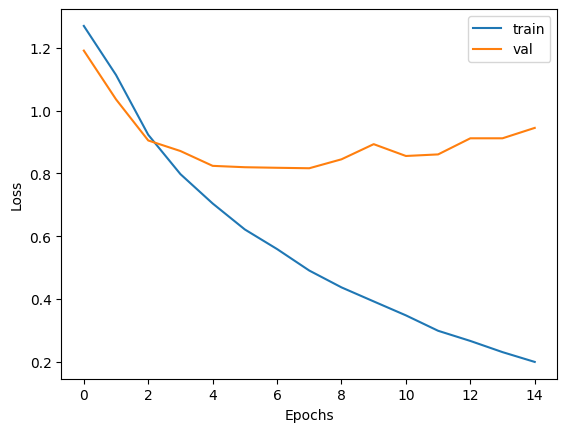

In [23]:
# Plotting learning curves
plt.figure()
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig('Measure of Loss',dpi=300, bbox_inches='tight')
plt.show()

In [24]:
def evaluate_model(model, test_loader):
    model.eval()
    total_correct = 0
    total_tested = 0
    gold_labels = []
    pred_labels = []

    for test_input_ids, test_labels in test_loader:
        with torch.no_grad():
            test_output = model(test_input_ids)
            predicted_labels = test_output.argmax(1)
            gold_labels.extend(test_labels.tolist())
            pred_labels.extend(predicted_labels.tolist())
            total_correct += (predicted_labels == test_labels).sum().item()
            total_tested += test_labels.size(0)

    accuracy = total_correct / total_tested * 100
    return accuracy, gold_labels, pred_labels

In [25]:
# Model Evaluation
test_accuracy, gold_labels, pred_labels = evaluate_model(trained_model, test_loader)
print(f"Test Accuracy: {test_accuracy:.2f}%")

# Calculation of F1 score
f1 = f1_score(gold_labels, pred_labels, average='macro')
print(f"F1 Score: {f1:.4f}")

recall = recall_score(gold_labels, pred_labels, average='macro')
print(f"Recall Score: {recall:.4f}")

precision = precision_score(gold_labels, pred_labels, average='macro')
print(f"Precision Score: {precision:.4f}")

Test Accuracy: 70.58%
F1 Score: 0.6386
Recall Score: 0.6299
Precision Score: 0.6568
